# <span style="color:blue;font-weight:bold;font-size:1.1em">Homework 4: Numeric Data Visualizations</span>

In the cell below, we read in a file containing insurance data.  

In [25]:
#Just run this cell 

from datascience import *
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np
import scipy.stats as stats
from scipy.stats import gaussian_kde
import warnings
warnings.simplefilter('ignore', FutureWarning)
import warnings
warnings.simplefilter('ignore', UserWarning)

## Read in a CSV data file from the web.
sky = Table.read_table('skyscrapers.csv')
pers = Table.read_table('http://faculty.ung.edu/rsinn/personality.csv')
insurance = Table.read_table("insurance.csv")

## In the cell below, we have the code for all our helper functions:
- **box()** and **boxes()**
- **density()** and **densities()**
- **describe()** and **describes()**

In [26]:
def describe(data, var = None):
  if isinstance(data, Table):
    data = data.column(var)
  names = np.array(["Mean", "Std Dev", "Sample Size", "Min", "Q1", "Median", "Q3", "Max"])
  values = np.array([round(np.mean(data),1), round(stats.tstd(data),2), len(data) - 1, min(data), np.percentile(data, 25), np.median(data), np.percentile(data, 75), max(data)])
  tab = Table().with_columns('Names', names, 'Values', values)  ;  transposed_tab = Table().with_columns( zip(tab.column('Names'), tab.column('Values')) ).show()
  return

def describes(data, num, group):
  dat = data.column(num)  ;  group_var = data.column(group)  ;  groups = np.unique(group_var)  ;  rows = []  ;  tab = Table(['Group', 'Mean', 'Std. Dev.', 'Sample Size', 'Min', 'Q1', 'Median', 'Q3', 'Max'])
  for g in groups:
    # Filter data for the current group
    sub_dat = dat[group_var == g]  ;    rows = [g, round(np.mean(sub_dat), 1), round(stats.tstd(sub_dat), 2), len(sub_dat) - 1, min(sub_dat), np.percentile(sub_dat, 25), np.median(sub_dat), np.percentile(sub_dat, 75), max(sub_dat)]        
    tab = tab.with_row(rows)
  tab.show()
  return 

def box(data, num = None, sm = False):
  if isinstance(data, Table):
    df = data.to_df()  ;  sns.boxplot(data=df, y=num, width=0.45, showmeans=sm)  ;
    plots.title(f'Boxplot of {num}')  ;  plots.xticks([], [])  ;  plots.show()  
  else:
    if num == True:
      sm = True  ;  num = 'Variable'
    if num == None:
      num = 'Variable'
    plots.figure(figsize=(6, 6))  ;  plots.boxplot(data, widths = 0.45, showmeans=sm)
    plots.title(f'Boxplot of {num}')  ;  plots.xticks([], [])  ;  plots.show()
  return

def boxes(data, num, cat, sm = False):
  if not isinstance(data, Table):
    print("ERROR: First input must be table name.")
  else:
    df = data.to_df()  ;  sns.boxplot(data=data, x=cat, y=num, width=0.75, showmeans=sm)
    plots.title(f'Boxplot of {num} Grouped by {cat}')  ;  plots.show()
  return

def density(data, num = None):
  if isinstance(data, Table):
    sns.kdeplot( data = data.column(num), bw_method="scott", bw_adjust=0.75, cut=3 )  ;  plots.title(f'Density Plot of {num}')  ;  plots.show()
  else:
    if num == None:
      num = 'Variable'  ;  sns.kdeplot( data = data, bw_method="scott", bw_adjust=0.75, cut=3 )  ;  plots.title(f'Density Plot of {num}')  ;  plots.show()
    else:
      sns.kdeplot( data = data, bw_method="scott", bw_adjust=0.75, cut=3 )  ;  plots.title(f'Density Plot of {num}')  ;  plots.show()
  return

def densities(tab, var, group_var):
  groups = tab.column(group_var) ;  unique_groups = np.unique(groups)  ;  plots.figure()
  for g in unique_groups:
    # Filter data for the current group
    mask = (groups == g)
    x = tab.column(var)[mask]   
    # Calculate KDE for the group subset
    kde = gaussian_kde(x)
    x_grid = np.linspace(x.min() - 1, x.max() + 1, 512)  ;    plots.plot(x_grid, kde(x_grid), label=str(g))   
  plots.title(f'Density Plot of {var} by {group_var}')  ;  plots.xlabel(f'{var}')  ;  plots.ylabel('Density')
  plots.legend()  ;  plots.show()
  return

In [27]:
insurance.show(5)

age,sex,bmi,children,smoker,region,price
19,female,27.9,0,yes,southwest,16884.9
18,male,33.77,1,no,southeast,1725.55
28,male,33,3,no,southeast,4449.46
33,male,22.705,0,no,northwest,21984.5
32,male,28.88,0,no,northwest,3866.86


## <span style="color:blue;font-weight:bold;font-size:1.1em">1. Histograms</span>

**1.1.** Make a histogram of **price** from the **insurance** table.  

In [28]:
insure_price = ...

**1.2** The histogram above is:
    1. Skewed left
    2. Roughly symmetric
    3. Skewed right
    
Enter 1, 2 or 3 below.

In [29]:
shape_answer = ...

**1.2b** Make a density plot of price from the insurance table.

In [30]:
insure_density = ...

**1.2c** Does the density plot change anything about your answers above?

*Write your answer here, replacing this text.*

In the cell below, we create a histogram with two groups overlayed.  The two groups are the male and female insurance customers. 

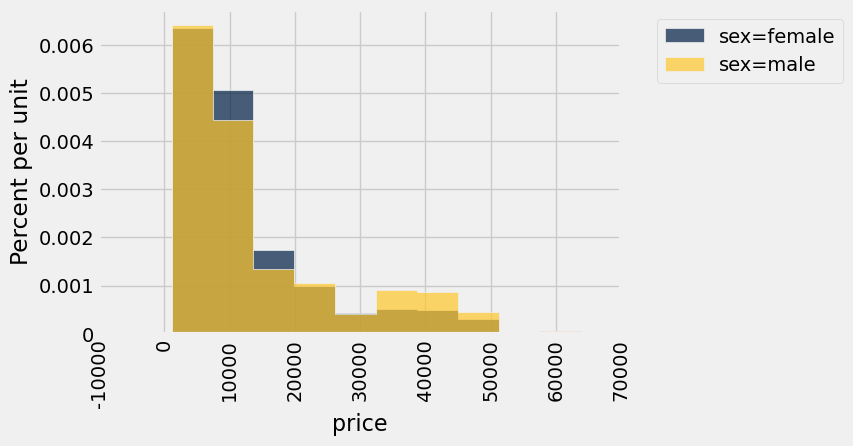

In [31]:
insurance.hist("price", group="sex")

**1.3** Does it appear that `sex` has any significant impact on the cost of insurance?

If "Yes", enter 1 below, otherwise enter 2.  

In [32]:
q1_3_answer = ...

**1.4** Create a histogram of `price` using `smoker` as a grouping variable, starting with the `insurance` data set.  

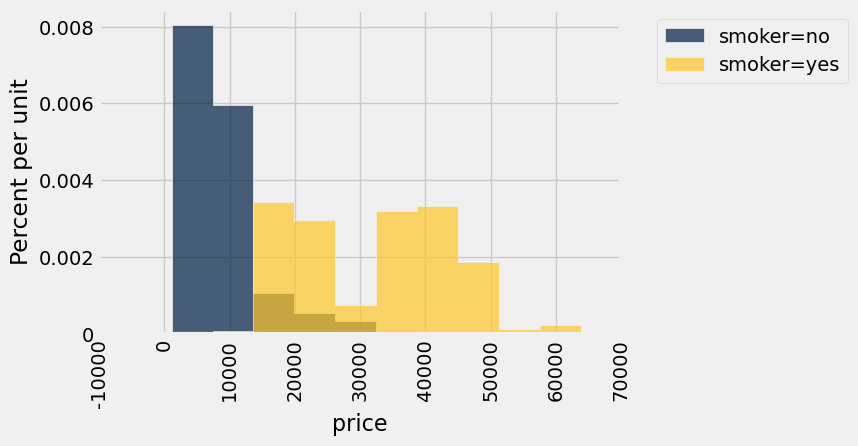

In [33]:
insurance.hist('price', group = 'smoker')

**1.5** Does it appear that `smoker` has any significant impact of the cost of insurance?

If "Yes", enter 1 below, otherwise enter 2.  

In [34]:
q1_5_answer = ...

## <span style="color:blue;font-weight:bold;font-size:1.1em">2. Scatterplots</span>

**2.1.** Using the `.scatter` method, make a scatterplot showing the relationship between `age` and `price`.  

In [37]:
scatter = ...

**2.2.** Start with the same scatterplot as the one in the previous problem, but include `group = "smoker"` as an additional argument inside the `.scatter`.

In [38]:
scatter_grouped = ...

**2.3.** In just a few words, what did the inclusion of `group = "smoker"` do to this scatterplot?

*Write your answer here.*

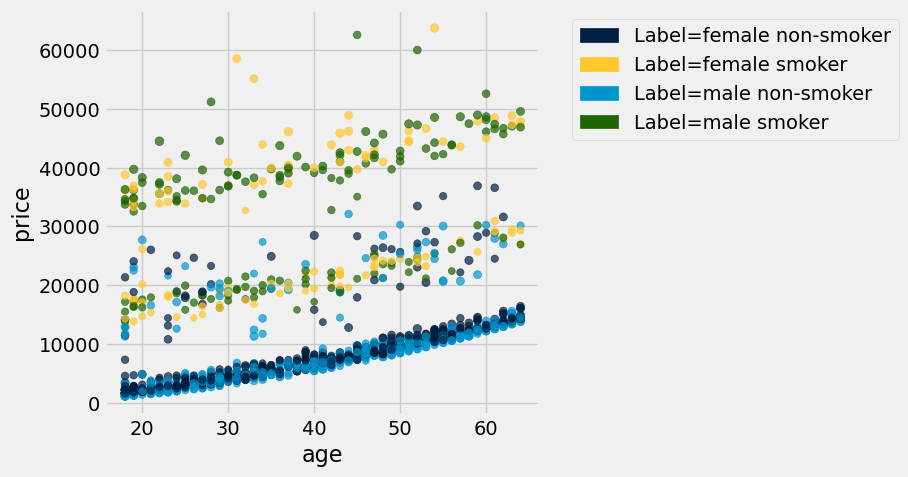

In [10]:
## Just run this cell

def new_label(x, y):
    if x == "yes":
        return y + " smoker"
    elif x == "no":
        return y + " non-smoker"

insurance.apply(new_label, "smoker", "sex")

insurance.with_column("Label", insurance.apply(new_label, "smoker", "sex") ).scatter("age", "price", group = "Label", sizes="bmi")

#insurance.with_columns("Label", insurance.apply(new_label, "smoker", "sex"), "bmi2", 100*insurance.column("bmi") ).scatter("age", "price", group = "Label", sizes="bmi2")


The scatterplot above shows four different groups of people; specifically, male and female crossed with smokers and non-smokers.  These four groups split into three clustered trends on this graph.  

**2.4.** Which of these four statements is true?

    1. The top cluster consists of smokers, but is a mixture of males and females.

    2. The top cluster consists of males, but is a mixture of smokers and non-smokers.

    3. The bottom cluster consists of females, but is a mixture of smokers and non-smokers.

    4. The bottom cluster consists of non-smokers, but is a mixture of both males and females.

    5. The middle cluster is a mixture of all four groups.  

Make an array of the statements you deem correct, using their numbers.  (More than one statement is correct.)

In [11]:
### put you answer here

true_statements_array = make_array(1,4,5)

true_statements_array

array([1, 4, 5])

## <span style="color:blue;font-weight:bold;font-size:1.1em">Boxplots</span>

In the cell below, we make 

**3.1** Using the **insurance** table, make side-by-side boxplots of prices grouped by sex.  

In [39]:
boxplots = ...

**3.1b.** Does there appear to be a significant difference between the prices each sex pays, on average, for insurance?

Enter a 1 if "Yes" and a 2 if "No".

In [13]:
q3_1_answer = ...

**3.2.**  Use the cell below to create a pair of side-by-side boxplots showing the distribution of `prices` split by whether the customer smokes.  If someone smokes the data shows "yes" under "smoker", and if not, it has "no". Also, please **include means** on the boxplots.

In [40]:
boxplots_smoker = ...

**3.3.** Does there appear to be a significant difference between the prices smoker and non-smokers pay, on average, for insurance?

Enter a 1 if "Yes" and a 2 if "No".

In [15]:
q3_3_answer = ...

**3.4** Look at the boxplot for the Smokers and estimate the value of $Q_3$.  

(Your professor may have referred to $Q_3$ as either the Third Quartile or the $75^{th}$ Percentile. These are all commonly used terms.) 

    1. About $34,000
2. About $41,000
    3. About $64,000
4. About $11,000

In [16]:
Q3_estimate = ...

## <span style="color:blue;font-weight:bold;font-size:1.1em">4. Representation</span>

Are males (or females) over-represented in this data set?  What about smokers?

To start to answer these questions, let's look at a table showing the counts of males and females.  

In [11]:
insurance.group("sex")

sex,count
female,662
male,676


**4.1** Start with the table from above and turn it into a horizontal bar chart using the `.barh` method.  

In [41]:
bar_chart = ...

If the difference between the lengths of the bars in the graph you just created is not very large with respect to the overall length of the bars, then we'd conlude that males and females were approximately equally represented in this data set.  


**4.2** Were males and females approximately equally represented?

Enter 1 is "Yes" and 2 if "No".

In [19]:
sex_equal_rep = ...

**4.3** Using the same method, create a barchart showing the distribution of smokers and non-smokers.

In [42]:
bar_chart_smoker = ...

**4.4** Is it accurate to say that there were roughly equal number of smokers and non-smokers in this data set?

Enter 1 if "Yes" and 2 if "No".

In [43]:
smoker_equal = ...

**4.5** Below we create a barchart showing two categories at once: sex and smoking status.  Based solely on this graph, would you agree that males are more likely to be smokers than females?  To put this another way, are there more male smokers in this data set than female smokers?

Enter 1 if "Yes" and 2 if "No".

In [44]:
insurance.pivot("smoker", "sex")

sex,no,yes
female,547,115
male,517,159


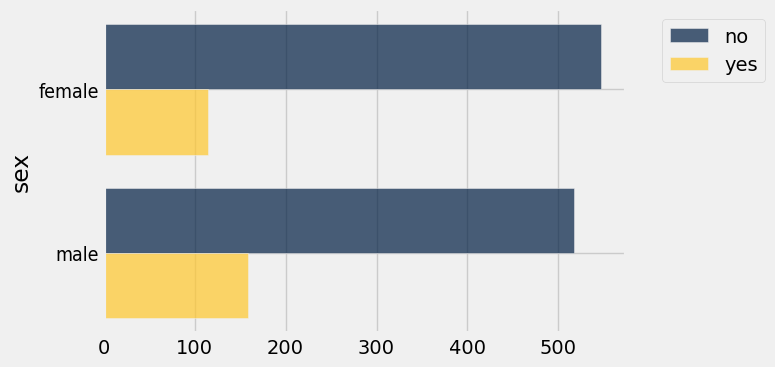

In [45]:
insurance.pivot("smoker", "sex").barh("sex")

In [46]:
males_more_likely_to_smoke = ...

## <span style="color:red;font-weight:bold;font-size:1.1em">Congratulations!</span>

You're done with this homework.  Download it as a pdf then submit both files to the appropriate folder in D2L.  